In [ ]:
!pip install biolearn matplotlib seaborn pandas numpy scipy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import gc

# Biolearn imports
from biolearn.data_library import DataLibrary
from biolearn.model_gallery import ModelGallery  # ← this line was missing

print("✅ All imports successful!")

✅ All imports successful!


In [ ]:
gc.collect()
print("✅ Memory cleaned")

library = DataLibrary()

print("Loading Dataset 1 (GSE40279)...")
data1 = library.get("GSE40279").load()
print(f"✅ Dataset 1: {data1.dnam.shape[1]} samples, {data1.dnam.shape[0]} CpG sites")
data1.dnam = data1.dnam.iloc[:, :200]
data1.metadata = data1.metadata.iloc[:200]
gc.collect()
print("✅ Dataset 1 trimmed to 200 samples")

print("\nLoading Dataset 2 (GSE51057)...")
data2 = library.get("GSE51057").load()
print(f"✅ Dataset 2: {data2.dnam.shape[1]} samples, {data2.dnam.shape[0]} CpG sites")
data2.dnam = data2.dnam.iloc[:, :200]
data2.metadata = data2.metadata.iloc[:200]
gc.collect()
print("✅ Dataset 2 trimmed to 200 samples")

✅ Memory cleaned
Loading Dataset 1 (GSE40279)...
✅ Dataset 1: 656 samples, 473034 CpG sites
✅ Dataset 1 trimmed to 200 samples

Loading Dataset 2 (GSE51057)...
✅ Dataset 2: 329 samples, 485577 CpG sites
✅ Dataset 2 trimmed to 200 samples


In [ ]:
clock_names = [
    "Horvathv1",
    "Horvathv2",
    "Hannum",
    "PhenoAge",
    "DunedinPACE",
    "YingCausAge",
    "Knight",
    "Bocklandt"
]

def run_clocks(data, dataset_name):
    results = {}
    chron_age = data.metadata['age'].values
    for clock in clock_names:
        try:
            print(f"  Running {clock}...")
            model = ModelGallery().get(clock)
            pred = model.predict(data)
            results[clock] = pred.values.flatten()
        except Exception as e:
            print(f"  ⚠️ {clock} failed: {e}")
            results[clock] = np.full(len(chron_age), np.nan)
    df = pd.DataFrame(results)
    df['ChronologicalAge'] = chron_age
    df.index = data.metadata.index
    print(f"✅ Done with {dataset_name}\n")
    return df

print("=== Dataset 1 (GSE40279) ===")
results1 = run_clocks(data1, "GSE40279")
gc.collect()

print("=== Dataset 2 (GSE51057) ===")
results2 = run_clocks(data2, "GSE51057")
gc.collect()

print("✅ All clocks done!")
print(results1.head())

=== Dataset 1 (GSE40279) ===
  Running Horvathv1...
  Running Horvathv2...
  Running Hannum...
  Running PhenoAge...
  Running DunedinPACE...
  Running YingCausAge...
  Running Knight...
  Running Bocklandt...
✅ Done with GSE40279

=== Dataset 2 (GSE51057) ===
  Running Horvathv1...
  Running Horvathv2...
  Running Hannum...
  Running PhenoAge...
  Running DunedinPACE...
  Running YingCausAge...
  Running Knight...
  Running Bocklandt...
✅ Done with GSE51057

✅ All clocks done!
           Horvathv1  Horvathv2     Hannum   PhenoAge  DunedinPACE  \
id                                                                   
GSM989827  52.171490  60.457122  67.134750  50.851113     0.745489   
GSM989828  75.456563  77.569278  86.167865  72.484114     0.806689   
GSM989829  62.613231  61.000440  68.953058  58.508157     1.121952   
GSM989830  54.260018  60.268563  68.895559  59.575270     1.050930   
GSM989831  62.957573  64.070016  67.932521  54.271417     0.835531   

           YingCausAge    

In [ ]:
gallery = ModelGallery()
print(dir(gallery))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'get', 'model_builders', 'model_definitions', 'search']


In [ ]:
gallery = ModelGallery()
results = gallery.search("")
print(results)

{}


In [ ]:
test_clocks = ["Knight", "Bocklandt", "Vidalin", "YingDamAge", "YingAdaptAge", "MEAT2", "DNAmTL", "Stubbs"]

for clock in test_clocks:
    try:
        model = ModelGallery().get(clock)
        pred = model.predict(data1)
        print(f"✅ {clock} works!")
    except Exception as e:
        print(f"⚠️ {clock} failed")

✅ Knight works!
✅ Bocklandt works!
⚠️ Vidalin failed
✅ YingDamAge works!
✅ YingAdaptAge works!
⚠️ MEAT2 failed
✅ DNAmTL works!
⚠️ Stubbs failed


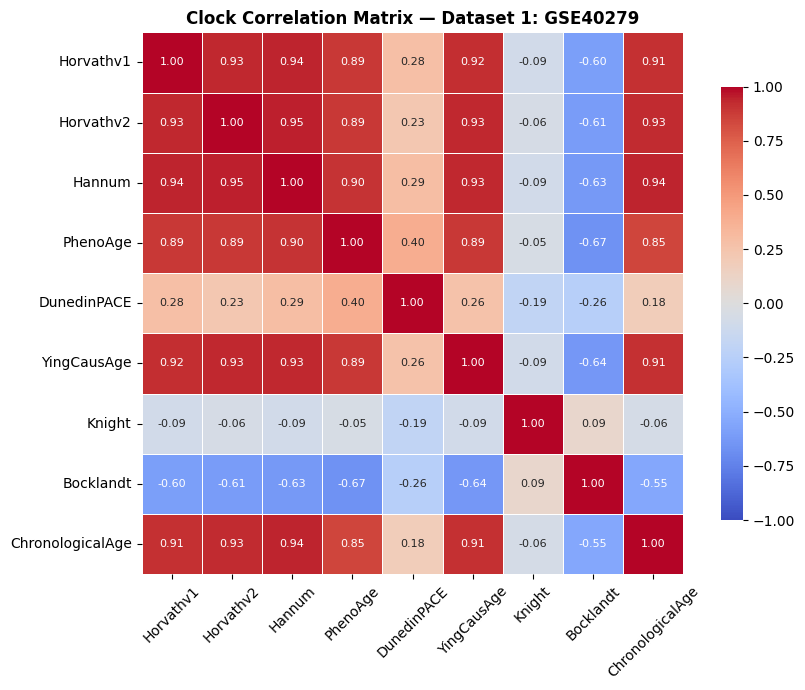

✅ Saved: corr_GSE40279.png


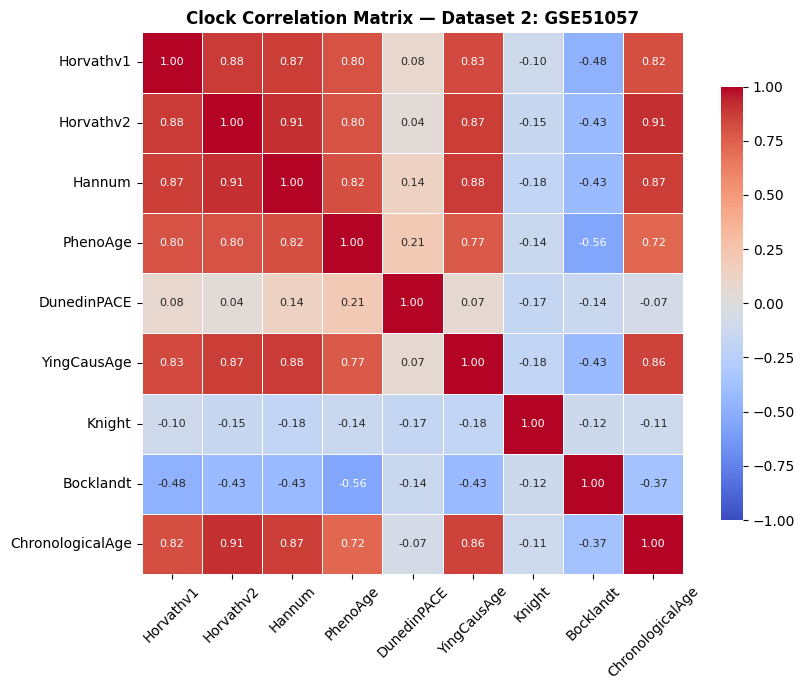

✅ Saved: corr_GSE51057.png


In [ ]:
for results, title, fname in [
    (results1, "Dataset 1: GSE40279", "corr_GSE40279.png"),
    (results2, "Dataset 2: GSE51057", "corr_GSE51057.png")
]:
    fig, ax = plt.subplots(figsize=(9, 7))
    clock_cols = clock_names + ['ChronologicalAge']
    corr = results[clock_cols].dropna().corr()

    sns.heatmap(
        corr,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        annot_kws={"size": 8}
    )
    ax.set_title(f"Clock Correlation Matrix — {title}", fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    gc.collect()
    print(f"✅ Saved: {fname}")

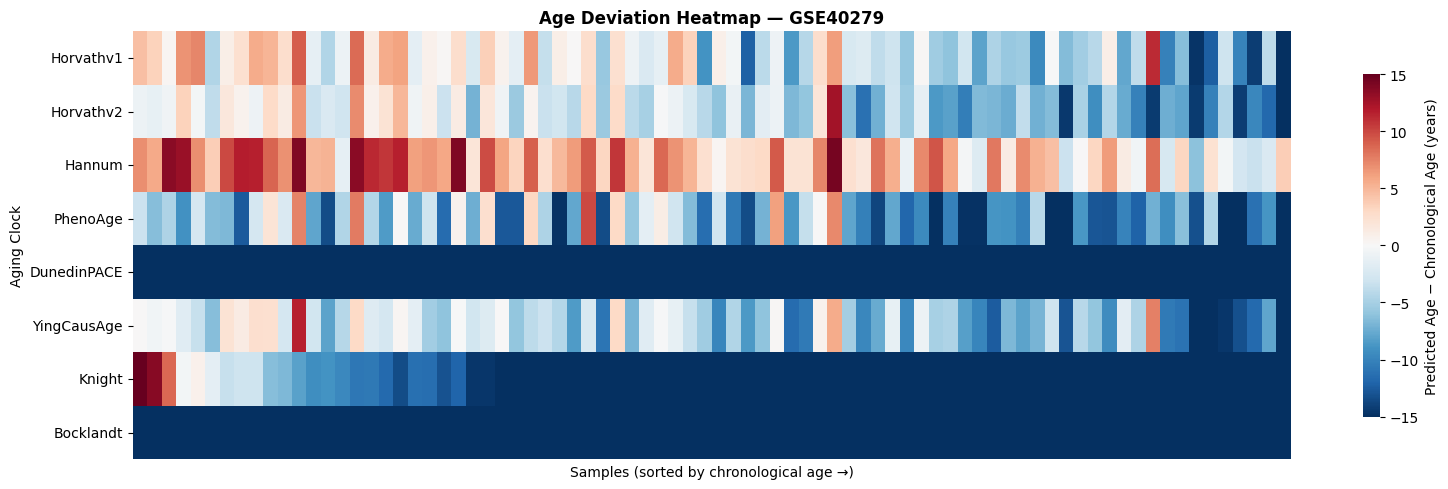

✅ Saved: deviation_GSE40279.png


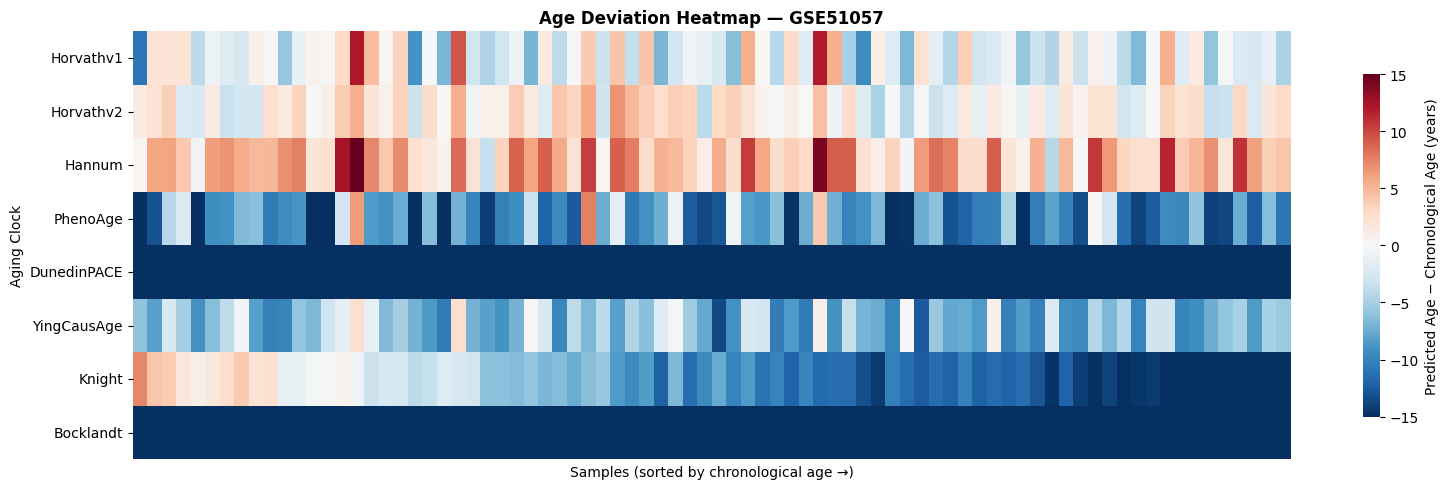

✅ Saved: deviation_GSE51057.png


In [ ]:
def make_deviation_heatmap(results, title, fname, n_samples=80):
    df = results.dropna().copy()
    if len(df) > n_samples:
        df = df.sample(n_samples, random_state=42).sort_values('ChronologicalAge')
    else:
        df = df.sort_values('ChronologicalAge')
    deviations = df[clock_names].subtract(df['ChronologicalAge'], axis=0)

    fig, ax = plt.subplots(figsize=(16, 5))
    sns.heatmap(
        deviations.T,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        vmin=-15, vmax=15,
        xticklabels=False,
        yticklabels=clock_names,
        cbar_kws={"label": "Predicted Age − Chronological Age (years)", "shrink": 0.8}
    )
    ax.set_xlabel("Samples (sorted by chronological age →)", fontsize=10)
    ax.set_ylabel("Aging Clock", fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    gc.collect()
    print(f"✅ Saved: {fname}")

make_deviation_heatmap(results1, "Age Deviation Heatmap — GSE40279", "deviation_GSE40279.png")
make_deviation_heatmap(results2, "Age Deviation Heatmap — GSE51057", "deviation_GSE51057.png")

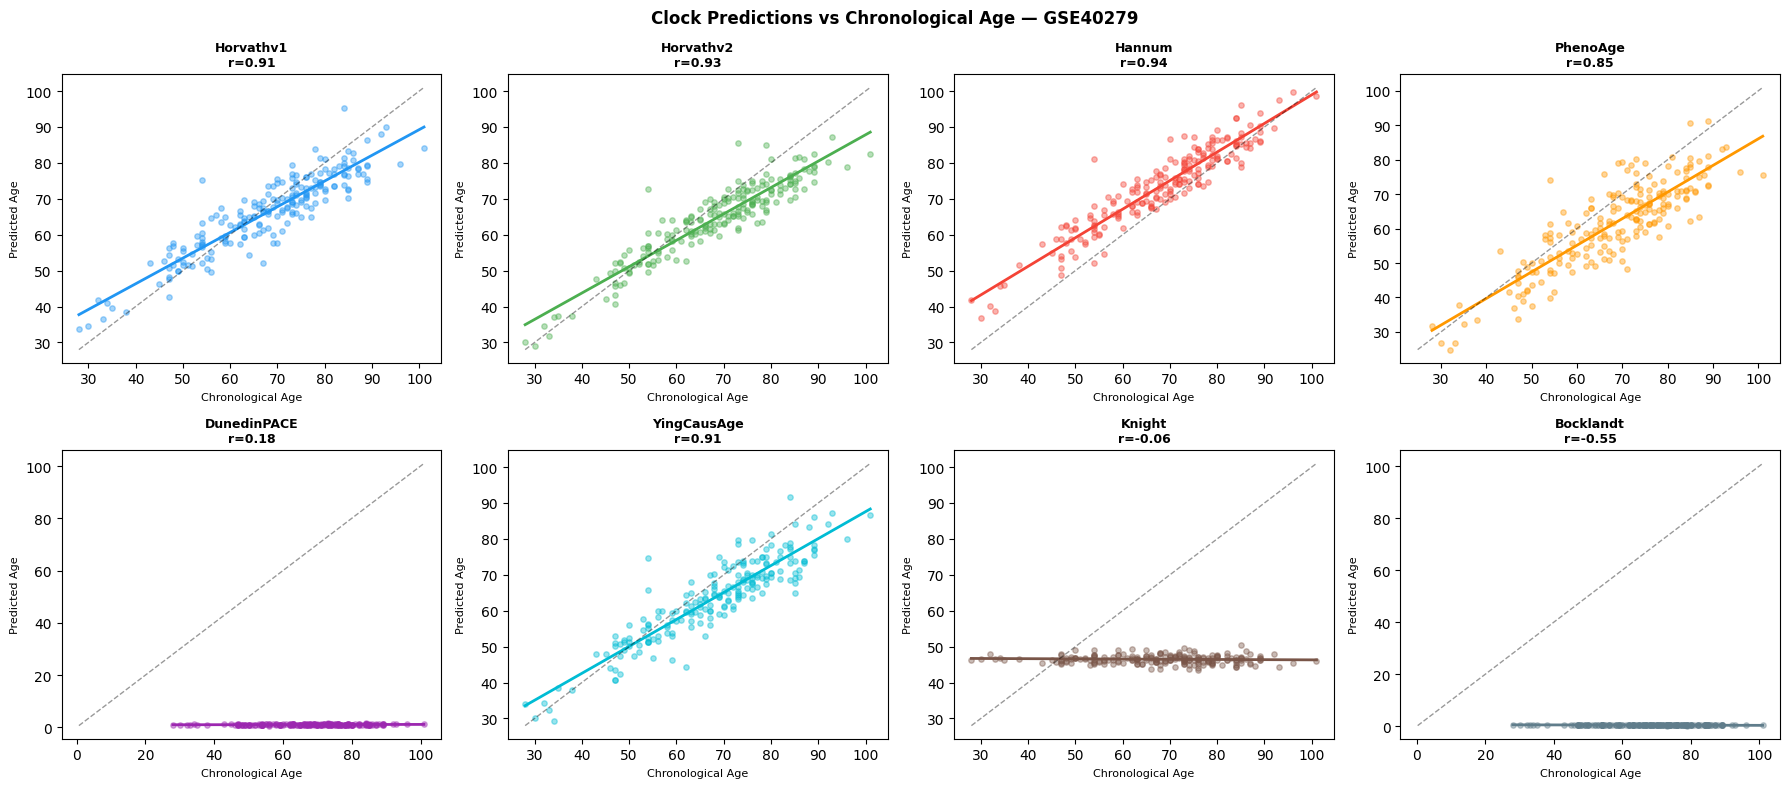

✅ Saved: scatter_GSE40279.png


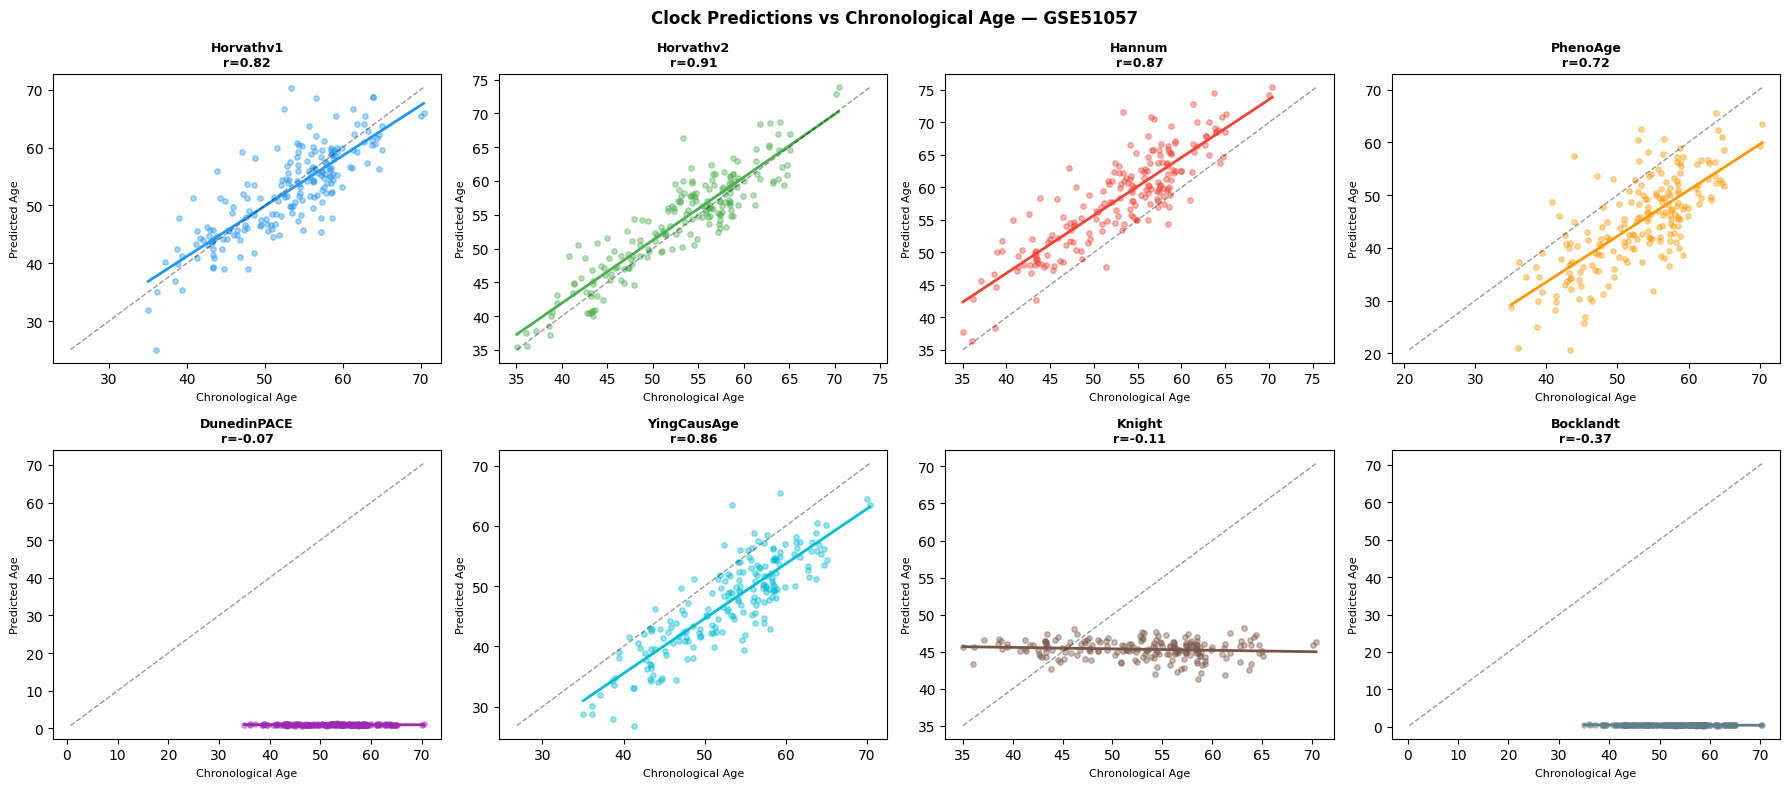

✅ Saved: scatter_GSE51057.png


In [ ]:
colors = ['#2196F3','#4CAF50','#F44336','#FF9800','#9C27B0','#00BCD4','#795548','#607D8B']

for results, ds_label in [(results1, "GSE40279"), (results2, "GSE51057")]:
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()

    for col, (clock, color) in enumerate(zip(clock_names, colors)):
        ax = axes[col]
        df = results[['ChronologicalAge', clock]].dropna()
        x = df['ChronologicalAge'].values
        y = df[clock].values

        if len(x) < 2:
            ax.set_title(f"{clock}\nno data")
            continue

        r, p = stats.pearsonr(x, y)
        ax.scatter(x, y, alpha=0.4, s=15, color=color)
        m, b = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, m * x_line + b, color=color, linewidth=2)
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax.plot(lims, lims, 'k--', alpha=0.4, linewidth=1)
        ax.set_xlabel("Chronological Age", fontsize=8)
        ax.set_ylabel("Predicted Age", fontsize=8)
        ax.set_title(f"{clock}\nr={r:.2f}", fontsize=9, fontweight='bold')

    plt.suptitle(f"Clock Predictions vs Chronological Age — {ds_label}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"scatter_{ds_label}.png", dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    gc.collect()
    print(f"✅ Saved: scatter_{ds_label}.png")

In [ ]:
from google.colab import files
files.download("corr_GSE40279.png")
files.download("corr_GSE51057.png")
files.download("deviation_GSE40279.png")
files.download("deviation_GSE51057.png")
files.download("scatter_GSE40279.png")
files.download("scatter_GSE51057.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>